In [1]:
# Weeks 2–3 skills: handle missing, engineer features like Title, Family_Size, Has_Cabin
# Import Pandas
import pandas as pd

# Step 1: Load the dataset directly from URL (no manual download needed)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)

# Save raw copy for submission
df_raw.to_csv('titanic_raw.csv', index=False)

# Step 2: Load and Inspect
df = df_raw.copy()

print("First 10 rows:")
display(df.head(10))

print("\nDataset Shape:", df.shape)
print("\nInfo (data types and non-null counts):")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics (numeric):")
display(df.describe())

print("\nSummary Statistics (all columns):")
display(df.describe(include='all'))
# Step 3: Cleaning Tasks
df_clean = df.copy()

# 1. Check and remove duplicates
print("Duplicates before:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Duplicates after:", df_clean.duplicated().sum())

# 2. Handle missing values
# Age: Impute with median (better than mean for skewed age data)
age_median = df_clean['Age'].median()
df_clean['Age'].fillna(age_median, inplace=True)

# Embarked: Fill with mode (most common port)
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(embarked_mode, inplace=True)

# Cabin: Too many missing (~77%) — create a new feature and drop original
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)
df_clean.drop('Cabin', axis=1, inplace=True)

# 3. Standardize strings (e.g., Sex and Embarked are already clean, but ensure consistency)
df_clean['Sex'] = df_clean['Sex'].str.lower()  # Just in case
df_clean['Embarked'] = df_clean['Embarked'].str.upper()

# 4. Handle outliers in Fare (optional but good practice)
# Cap extreme fares at 99th percentile
fare_99 = df_clean['Fare'].quantile(0.99)
df_clean['Fare'] = df_clean['Fare'].clip(upper=fare_99)

# 5. Create new features
df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# Extract Title from Name (e.g., Mr, Mrs, Miss)
df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_clean['Title'] = df_clean['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
    'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_clean['Title'] = df_clean['Title'].replace(['Mlle','Ms'], 'Miss')
df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')

# 6. Drop unnecessary columns
df_clean.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Final cleaned view
print("\nCleaned Dataset Preview:")
display(df_clean.head())

# Save cleaned version
df_clean.to_csv('titanic_cleaned.csv', index=False)
# Step 4: Exploration Tasks
print("Survival Rate Overall:")
print(df_clean['Survived'].value_counts(normalize=True))

print("\nSurvival Rate by Sex:")
display(df_clean.groupby('Sex')['Survived'].mean())

print("\nSurvival Rate by Pclass:")
display(df_clean.groupby('Pclass')['Survived'].mean())

print("\nSurvival Rate by Age Group:")
# Create age bins
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 12, 18, 35, 60, 100], 
                              labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
display(df_clean.groupby('Age_Group')['Survived'].mean())

print("\nValue Counts - Embarked:")
print(df_clean['Embarked'].value_counts())

print("\nValue Counts - Title:")
print(df_clean['Title'].value_counts())

print("\nAverage Fare and Age by Survival:")
display(df_clean.groupby('Survived')[['Age', 'Fare']].mean())

print("\nFamily Size vs Survival:")
display(df_clean.groupby('Family_Size')['Survived'].mean())

print("\nFinal Clean Dataset Summary:")
display(df_clean.describe(include='all'))

First 10 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



Dataset Shape: (891, 12)

Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket   

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Summary Statistics (all columns):


...

,Age,Fare
Survived,,
0,30.028233,22.066908
1,28.291433,45.925542



Family Size vs Survival:


Family_Size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


Final Clean Dataset Summary:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Family_Size,Title,Age_Group
count,891.000000,891.000000,891,891.000000,891.000000,891.000000,891.000000,891,891.000000,891.000000,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,NaN,NaN,5,5
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,NaN,NaN,Mr,Young Adult
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,646,NaN,NaN,517,535
mean,0.383838,2.308642,NaN,29.361582,0.523008,0.381594,31.224767,NaN,0.228956,1.904602,NaN,NaN
std,0.486592,0.836071,NaN,13.019697,1.102743,0.806057,42.524125,NaN,0.420397,1.613459,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,0.000000,1.000000,NaN,NaN
25%,0.000000,2.000000,NaN,22.000000,0.000000,0.000000,7.910400,NaN,0.000000,1.000000,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,0.000000,1.000000,NaN,NaN
75%,1.000000,3.000000,NaN,35.000000,1.000000,0.000000,31.000000,NaN,0.000000,2.000000,NaN,NaN


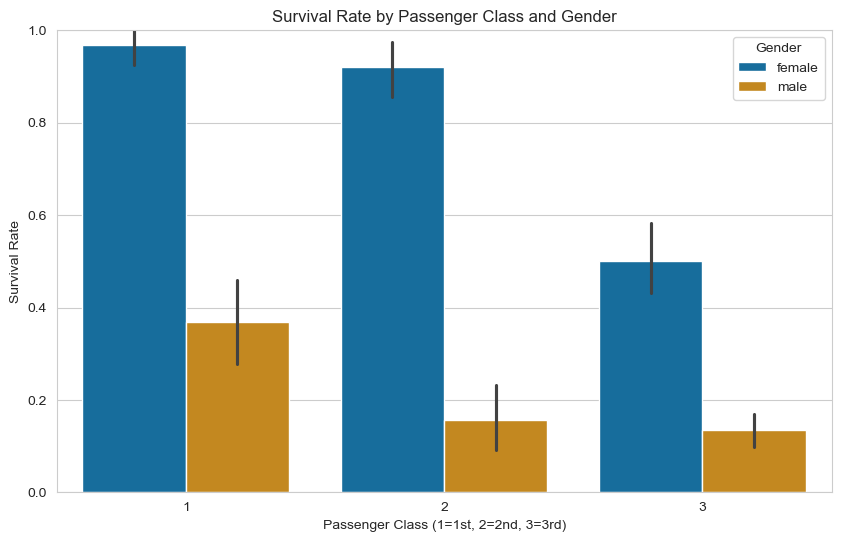

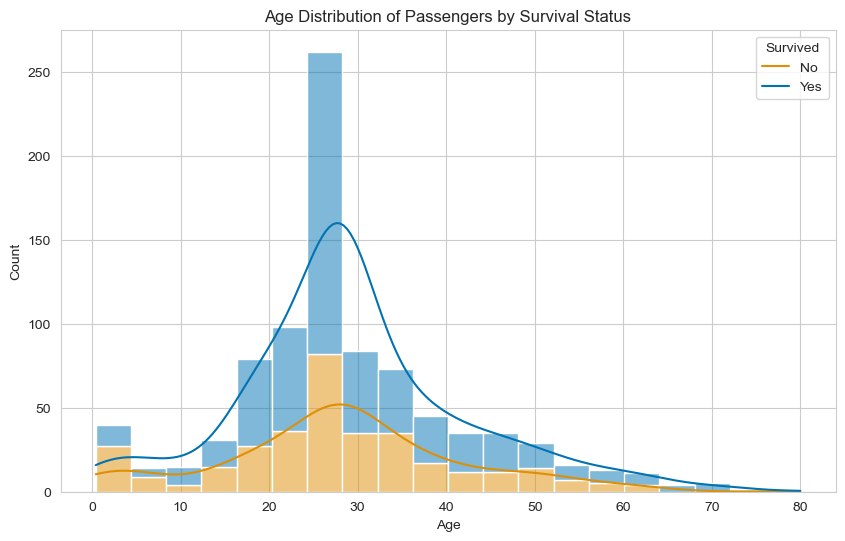

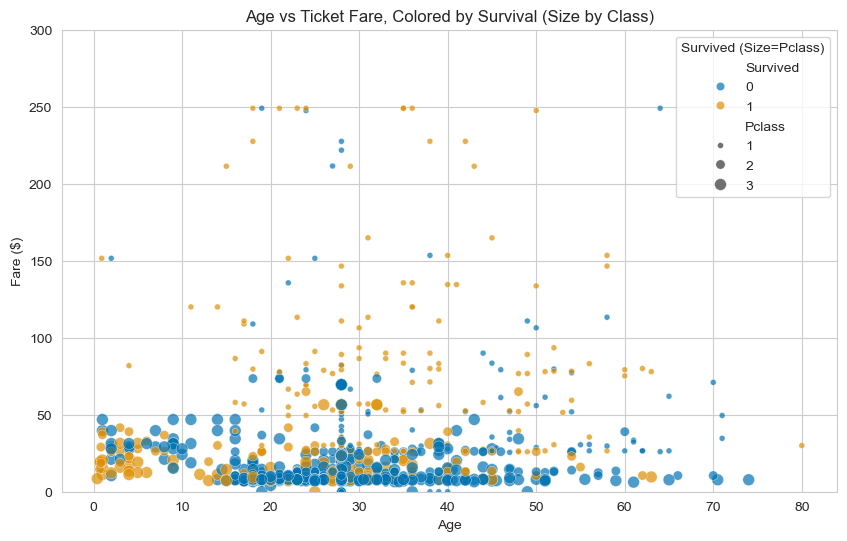

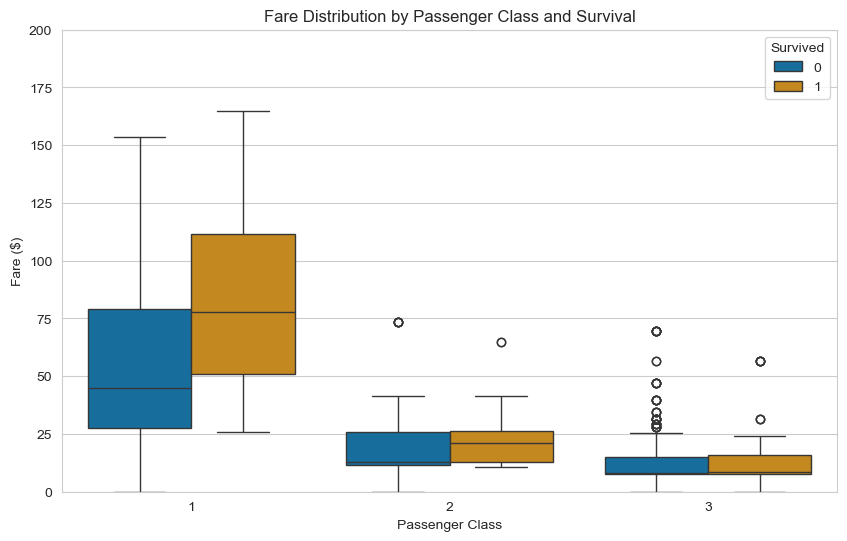

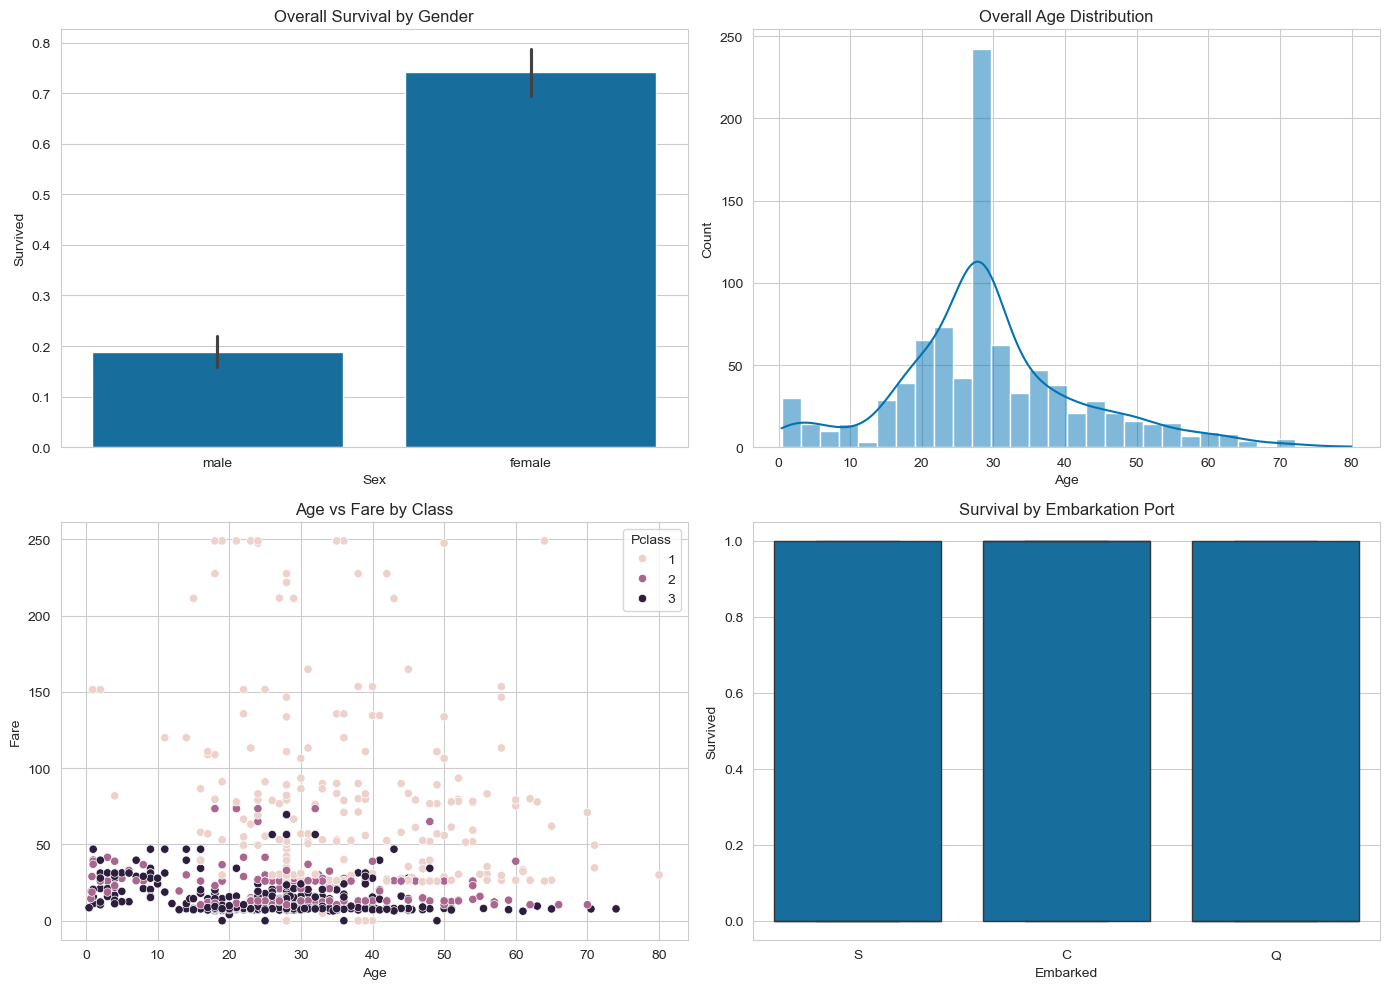

In [8]:
# Weeks 2–3 skills: handle missing, engineer features like Title, Family_Size, Has_Cabin
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned Titanic dataset (from Week 2)
df = pd.read_csv('titanic_cleaned.csv')  # Or load fresh if needed

# Set style for professional plots
sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (10, 6)

# Plot 1: Bar Plot - Survival Rate by Gender and Class
plt.figure()
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', errorbar='ci')
plt.title('Survival Rate by Passenger Class and Gender')
plt.xlabel('Passenger Class (1=1st, 2=2nd, 3=3rd)')
plt.ylabel('Survival Rate')
plt.legend(title='Gender')
plt.ylim(0, 1)
plt.savefig('Survival Rate by Passenger Class and Gender', dpi=300, bbox_inches='tight')
plt.show()
# Insight: Females in 1st/2nd class had ~90-100% survival; males much lower.

# Plot 2: Histogram - Age Distribution by Survival
plt.figure()
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=20, kde=True)
plt.title('Age Distribution of Passengers by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.savefig('Age Distribution of Passengers by Survival Status', dpi=300, bbox_inches='tight')
plt.show()
# Insight: Younger passengers (children) had higher stacked survival bars.

# Plot 3: Scatter Plot - Age vs Fare, colored by Survival
plt.figure()
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.7, size='Pclass')
plt.title('Age vs Ticket Fare, Colored by Survival (Size by Class)')
plt.xlabel('Age')
plt.ylabel('Fare ($)')
plt.ylim(0, 300)  # Focus on main data, reduce outlier impact
plt.legend(title='Survived (Size=Pclass)')
plt.savefig('Age vs Ticket Fare, Colored by Survival (Size by Class)', dpi=300, bbox_inches='tight')
plt.show()
# Insight: Higher fares (1st class) cluster with more survivors; outliers visible.

# Plot 4: Box Plot - Fare Distribution by Class and Survival
plt.figure()
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived')
plt.title('Fare Distribution by Passenger Class and Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.ylim(0, 200)  # Zoom for clarity
plt.legend(title='Survived')
plt.savefig('Fare Distribution by Passenger Class and Survival', dpi=300, bbox_inches='tight')
plt.show()
# Insight: 1st class had higher/ wider fares; survivors often paid more.

# Bonus: Multi-panel figure (subplots) combining insights
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0,0])
axes[0,0].set_title('Overall Survival by Gender')

sns.histplot(data=df, x='Age', kde=True, ax=axes[0,1])
axes[0,1].set_title('Overall Age Distribution')

sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass', ax=axes[1,0])
axes[1,0].set_title('Age vs Fare by Class')

sns.boxplot(data=df, x='Embarked', y='Survived', ax=axes[1,1])
axes[1,1].set_title('Survival by Embarkation Port')

plt.tight_layout()
plt.show()

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Has_Cabin  \
0         0       3    male  22.0      1      0   7.2500        S          0   
1         1       1  female  38.0      1      0  71.2833        C          1   
2         1       3  female  26.0      0      0   7.9250        S          0   
3         1       1  female  35.0      1      0  53.1000        S          1   
4         0       3    male  35.0      0      0   8.0500        S          0   

   Family_Size Title  
0            2    Mr  
1            2   Mrs  
2            1  Miss  
3            2   Mrs  
4            1    Mr  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    object 
 3   Age          891 non-null    float64
 4   SibS

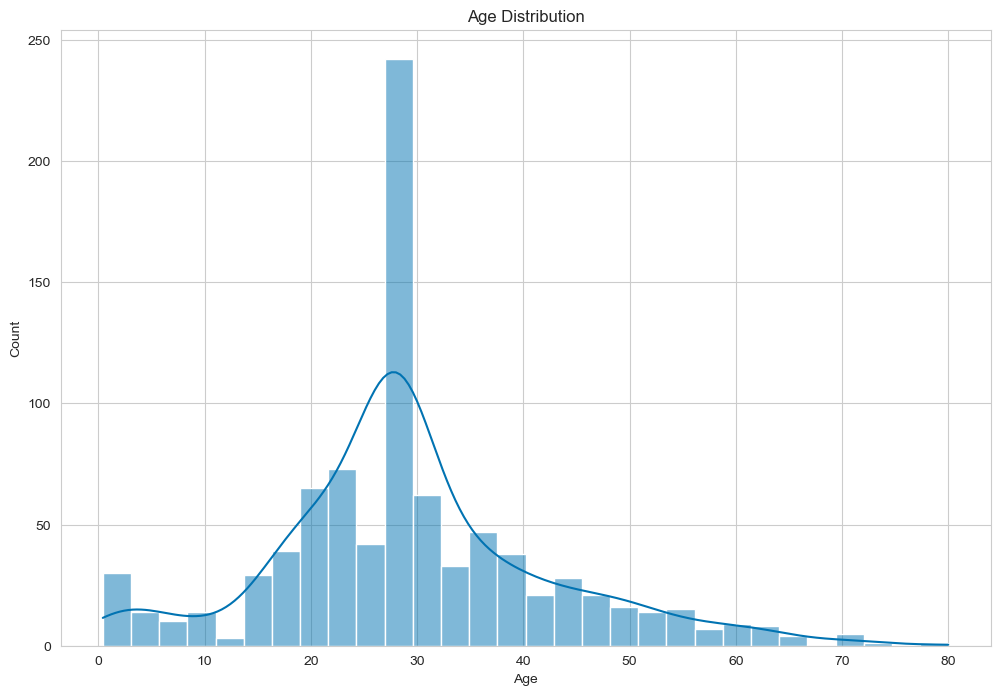

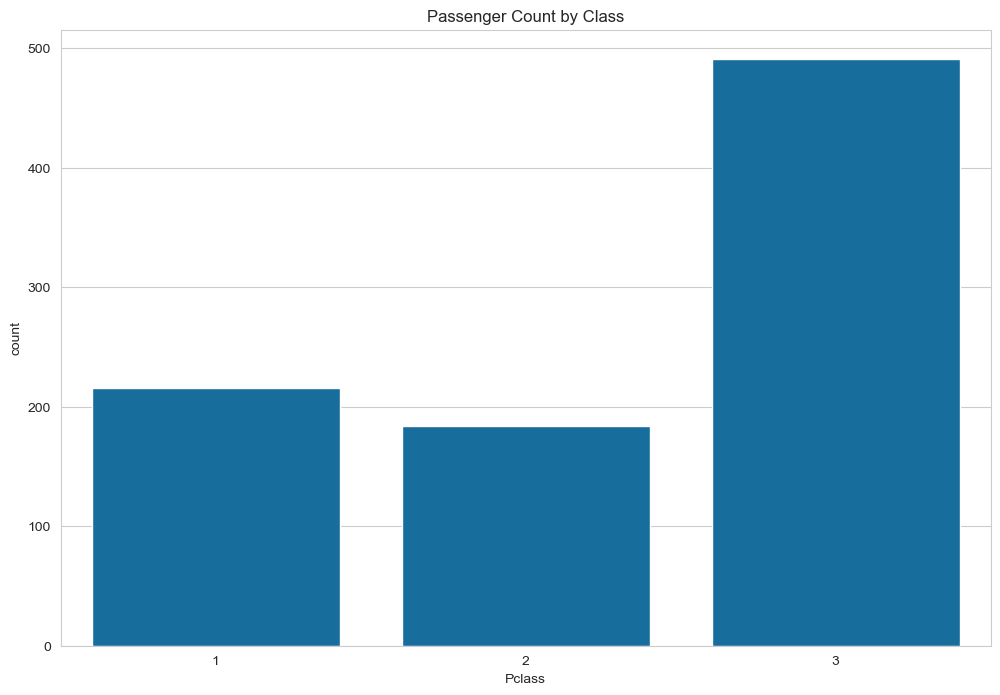


Survival Rate:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


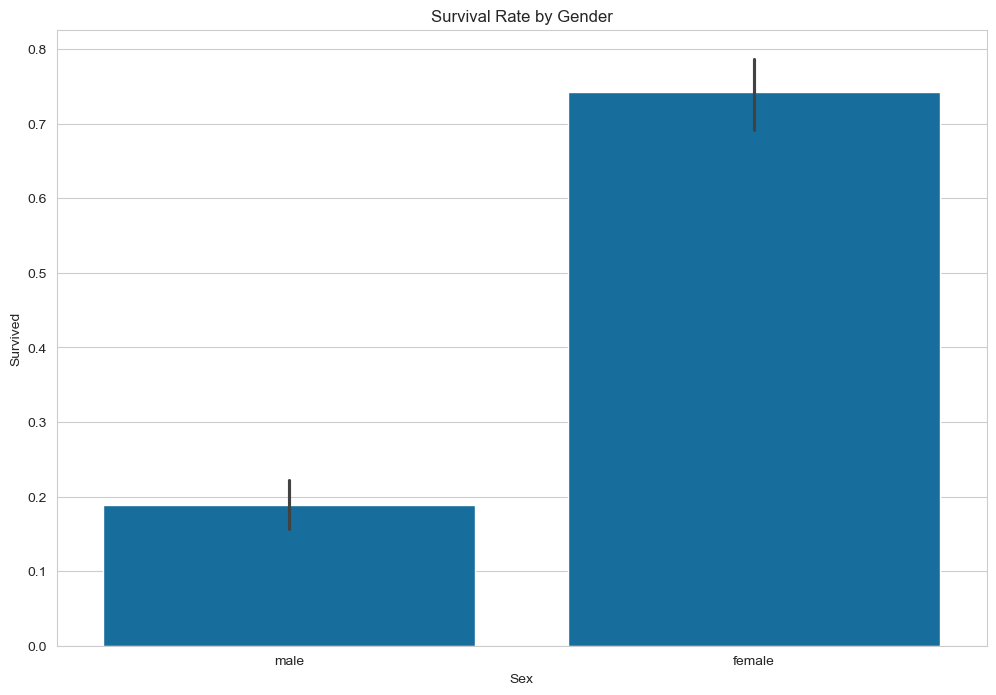

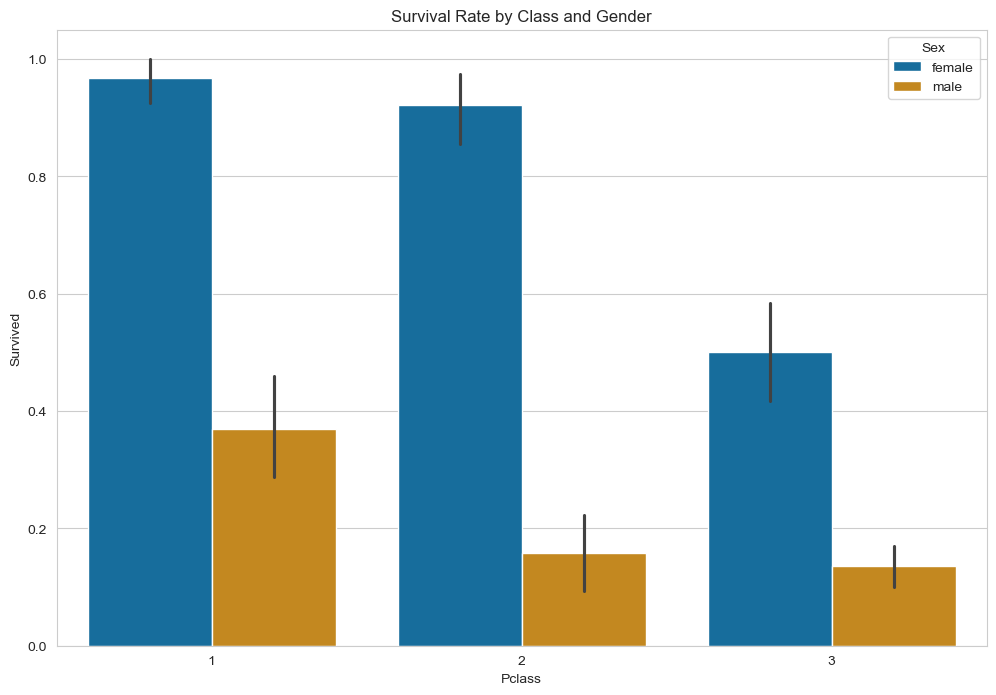

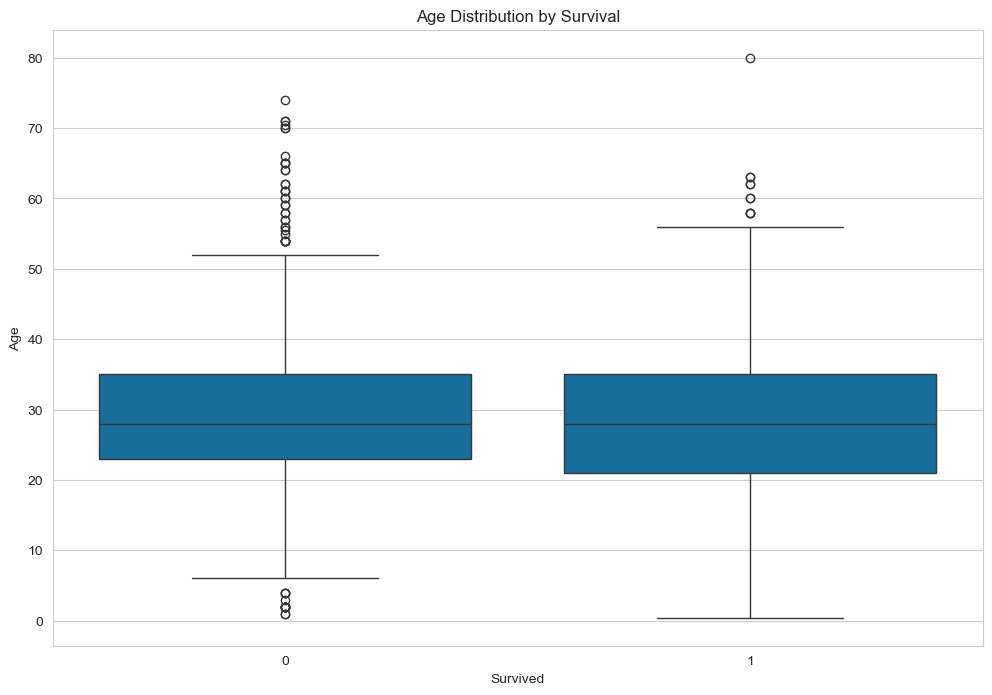

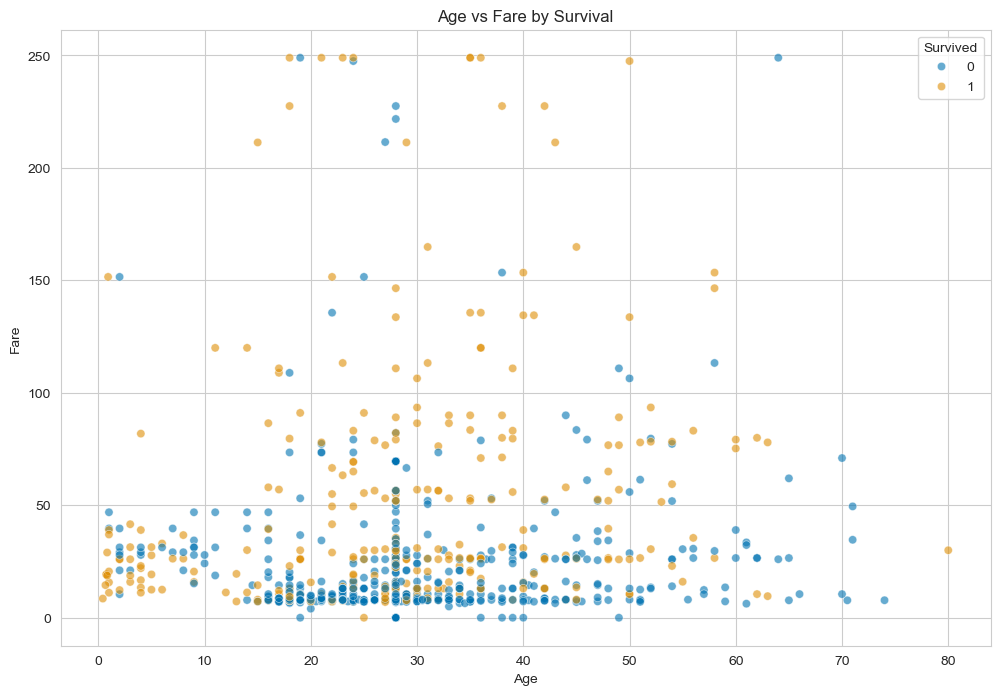

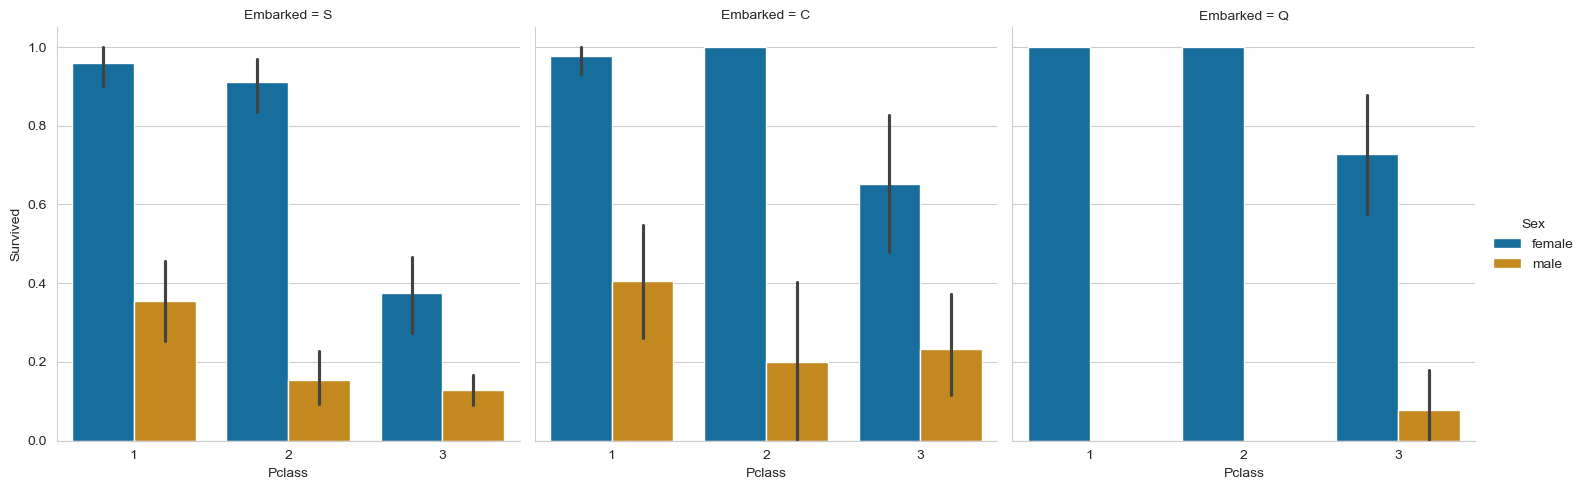

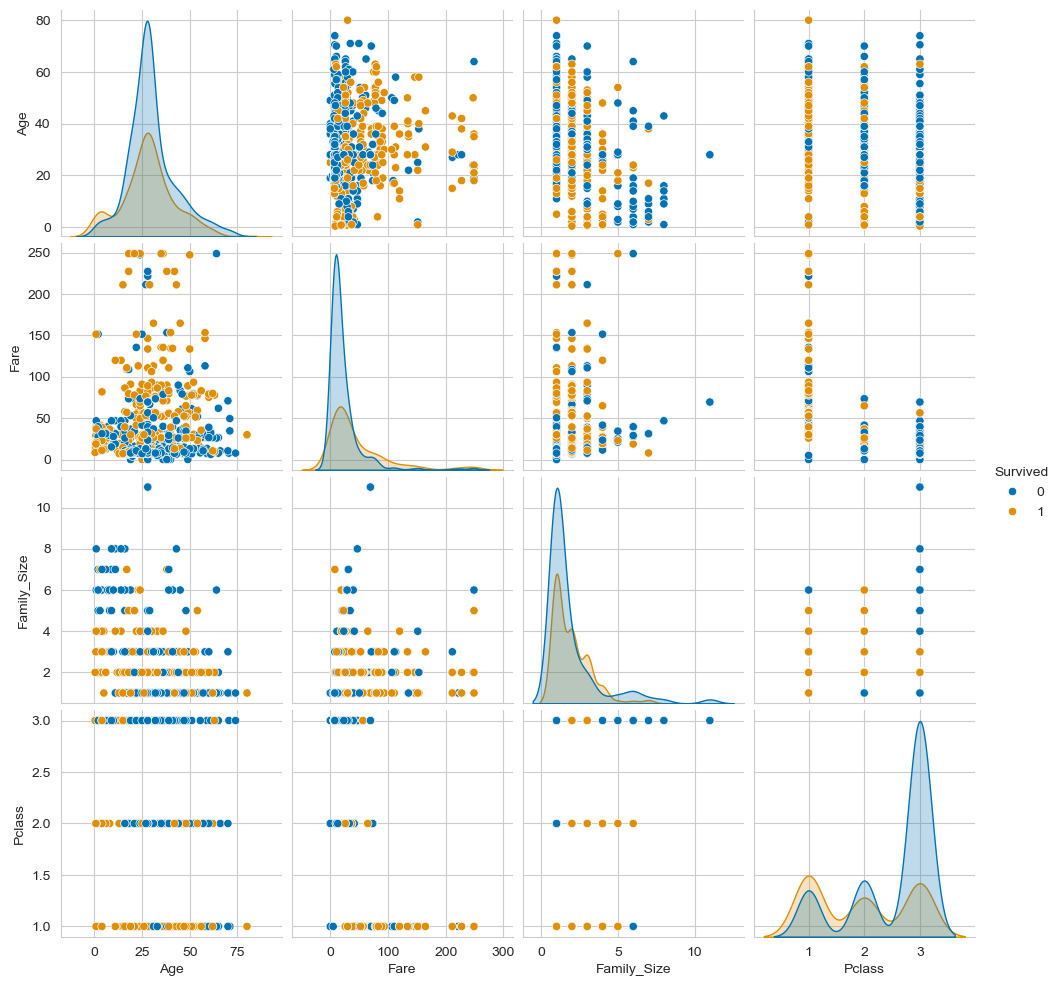

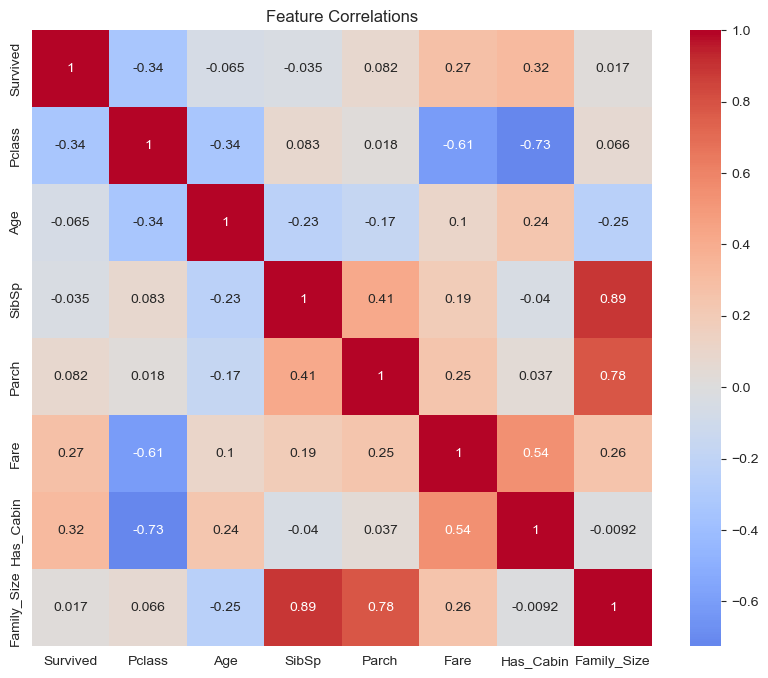

In [9]:
# Week 4: univariate, bivariate, multivariate plots
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Visualization and Style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)


# Load cleaned Titanic dataset

df = pd.read_csv("titanic_cleaned.csv")

# Preview dataset
print(df.head())
print("\nDataset Info:")
df.info()


#Distribution
sns.histplot(data=df, x="Age", kde=True, bins=30)
plt.title("Age Distribution")
plt.savefig('Age Distribution', dpi=300, bbox_inches='tight')
plt.show()

sns.countplot(data=df, x="Pclass")
plt.title("Passenger Count by Class")
plt.savefig('Passenger Count by Class', dpi=300, bbox_inches='tight')
plt.show()

# Survival proportions
print("\nSurvival Rate:")
print(df["Survived"].value_counts(normalize=True))


# Survival by Key Categories
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Gender")
plt.savefig('Survival Rate by Gender', dpi=300, bbox_inches='tight')
plt.show()


sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Gender")
plt.savefig('Survival Rate by Class and Gender', dpi=300, bbox_inches='tight')
plt.show()



# Numerical Relationships
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age Distribution by Survival")
plt.savefig('Age Distribution by Survival', dpi=300, bbox_inches='tight')
plt.show()

# Age vs Fare colored by survival
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived",
    alpha=0.6
)
plt.title("Age vs Fare by Survival")
plt.savefig('Age vs Fare by Survival', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------
# Faceted Plots

sns.catplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    col="Embarked",
    kind="bar"
)
plt.show()


# Pairplots for a quick review
pairplot_cols = ["Age", "Fare", "Family_Size", "Pclass", "Survived"]
sns.pairplot(df[pairplot_cols], hue="Survived")
plt.show()


# Correlation heatmap 

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlations")
plt.savefig('Feature Correlations', dpi=300, bbox_inches='tight')
plt.show()

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       110
           1       0.77      0.81      0.79        69

    accuracy                           0.83       179
   macro avg       0.82      0.83      0.82       179
weighted avg       0.83      0.83      0.83       179

AUC: 0.8662714097496705


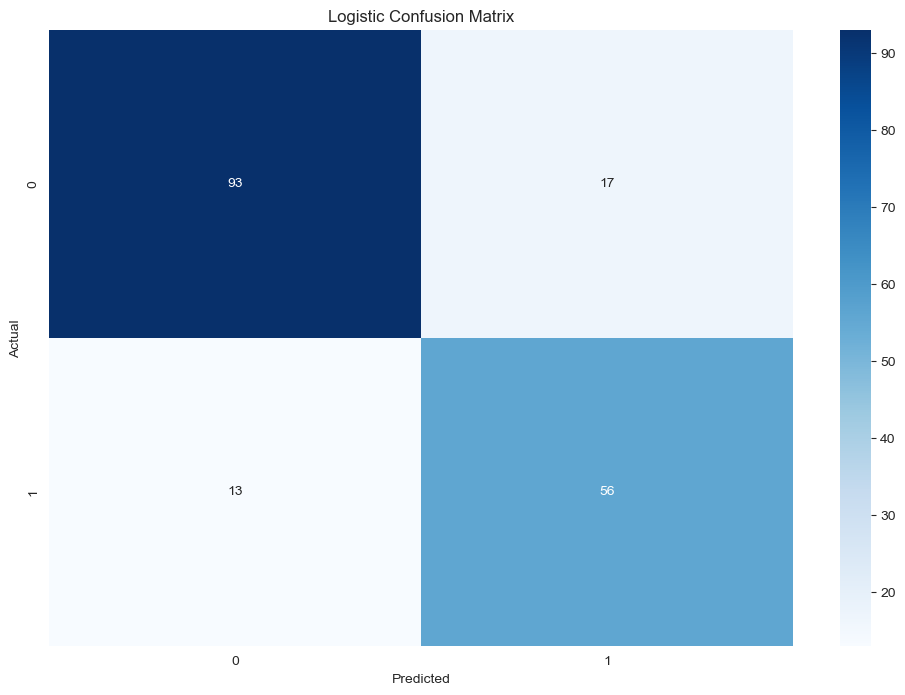

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       110
           1       0.80      0.58      0.67        69

    accuracy                           0.78       179
   macro avg       0.79      0.74      0.75       179
weighted avg       0.78      0.78      0.77       179



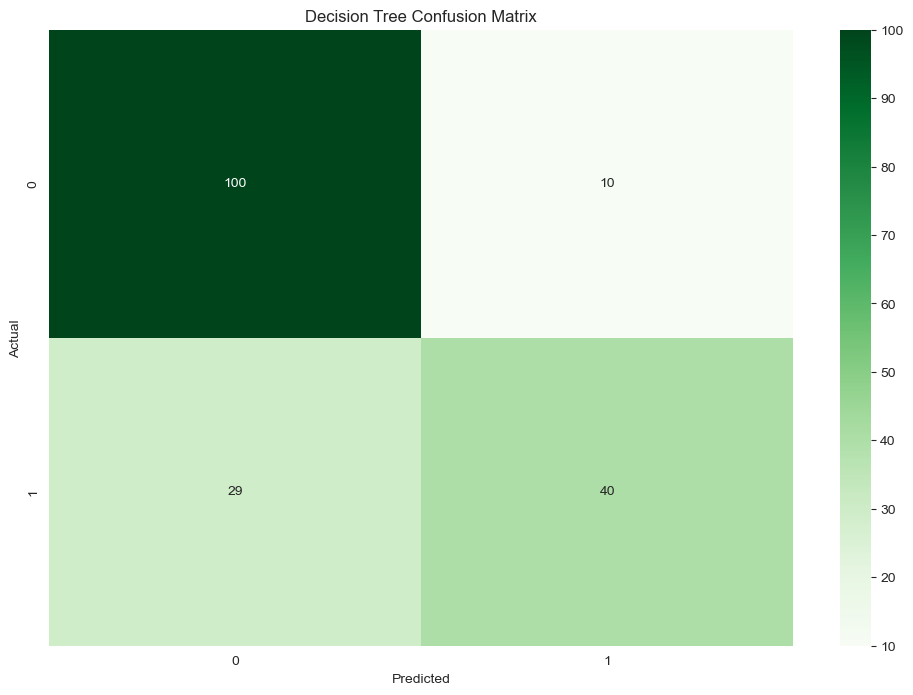

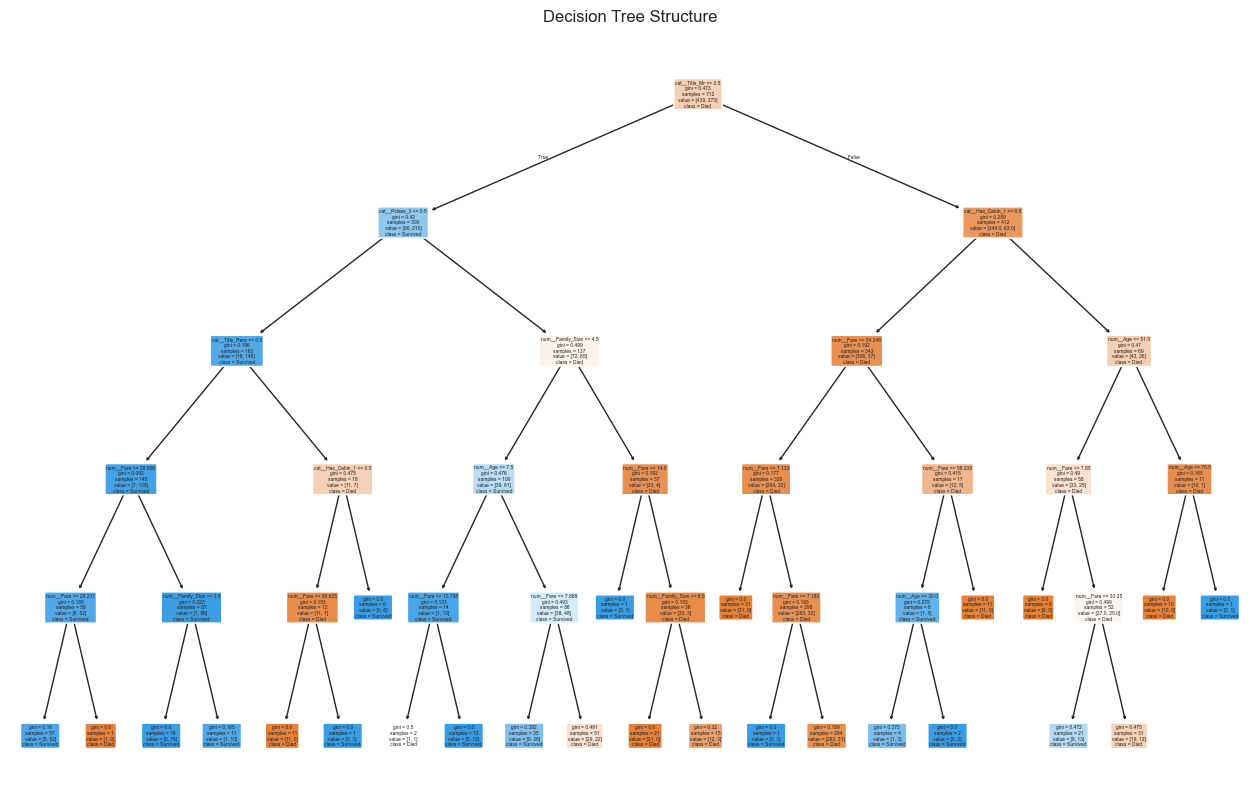

In [10]:
# Weeks 5–6: linear regression on Fare + logistic/decision tree on Survived
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('titanic_cleaned.csv')

# Features (include engineered ones like Title, Family_Size, Has_Cabin)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Family_Size', 'Has_Cabin']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'Has_Cabin']
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'Family_Size']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

log_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))  # Handle imbalance
])

log_pipe.fit(X_train, y_train)
log_pred = log_pipe.predict(X_test)
log_prob = log_pipe.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, log_pred))
print("AUC:", roc_auc_score(y_test, log_prob))

# Confusion Matrix
cm_log = confusion_matrix(y_test, log_pred)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Logistic Confusion Matrix', dpi=300, bbox_inches='tight')
plt.show()



tree_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])

tree_pipe.fit(X_train, y_train)
tree_pred = tree_pipe.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test, tree_pred))

# Confusion Matrix
cm_tree = confusion_matrix(y_test, tree_pred)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Decision Tree Confusion Matrix', dpi=300, bbox_inches='tight')
plt.show()

# Visualize Tree (limited depth)
plt.figure(figsize=(16,10))
encoded_features = tree_pipe.named_steps['preprocessor'].get_feature_names_out()
plot_tree(tree_pipe.named_steps['classifier'], feature_names=encoded_features, 
          class_names=['Died', 'Survived'], filled=True, rounded=True)
plt.title('Decision Tree Structure')
plt.savefig('Decision Tree Structure', dpi=300, bbox_inches='tight')
plt.show()





MSE: 857.97
RMSE: 29.29
MAE: 17.23
R²: 0.433
Intercept: 71.79306707007034


,Feature,Coefficient,Abs_Coefficient
1,Pclass_3,-73.837687,73.837687
0,Pclass_2,-63.799316,63.799316
5,Title_Miss,20.189043,20.189043
7,Title_Mrs,11.344227,11.344227
4,Embarked_S,-11.014558,11.014558
3,Embarked_Q,-10.093307,10.093307
11,Family_Size,7.577325,7.577325
8,Title_Rare,-7.403592,7.403592
6,Title_Mr,7.286184,7.286184
2,Sex_male,3.974135,3.974135


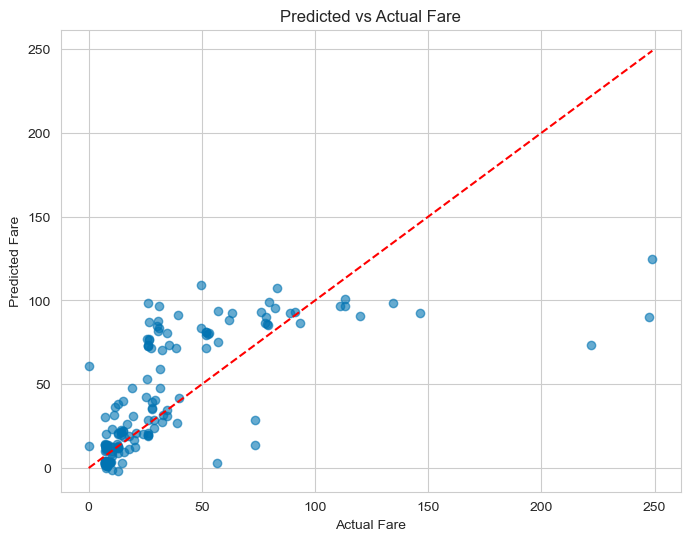

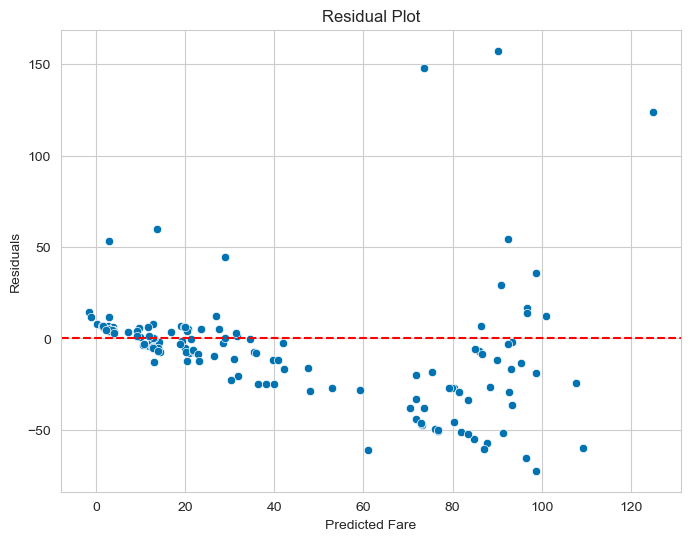

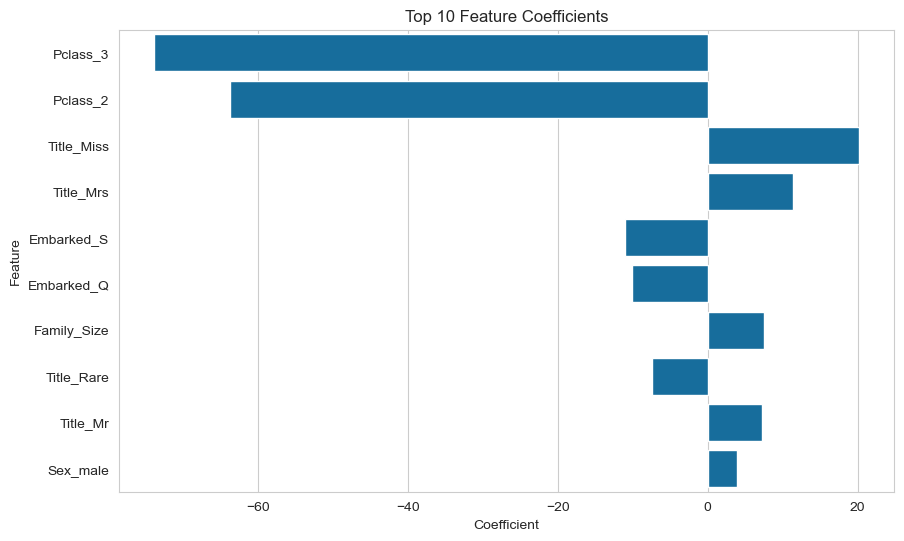

In [11]:
# Weeks 5–6: linear regression on Fare + logistic/decision tree on Survived
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('titanic_cleaned.csv')

# Features: Select relevant ones
features = ['Pclass', 'Age', 'Family_Size', 'Sex', 'Embarked', 'Title', 'Has_Cabin']
X = df[features]
y = df['Fare']  # Target: continuous

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessor: One-hot encode categoricals
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'Has_Cabin']
numerical_features = ['Age', 'Family_Size']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Full pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")
# Expect R² ~0.4–0.5 — decent given Fare variance


# Get feature names after encoding
encoded_cat_features = model.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(encoded_cat_features) + numerical_features

coeffs = model.named_steps['regressor'].coef_
intercept = model.named_steps['regressor'].intercept_

coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coeffs})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("Intercept:", intercept)
display(coef_df.head(10))
# e.g., Pclass_1 positive → higher fare; Title_Mr negative relative to others


# Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Predicted vs Actual Fare')
plt.savefig('Predicted vs Actual Fare', dpi=300, bbox_inches='tight')
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.savefig('Residual Plot', dpi=300, bbox_inches='tight')
plt.show()

# Coefficient importance bar plot
plt.figure(figsize=(10,6))
top_coeffs = coef_df.head(10)
sns.barplot(data=top_coeffs, x='Coefficient', y='Feature')
plt.title('Top 10 Feature Coefficients')
plt.savefig('Top 10 Feature Coefficients', dpi=300, bbox_inches='tight')
plt.show()



In [1]:
# Project Overview: 
# To construct a well-organized data science workflow using the Titanic dataset. 
# The goal is to produce a shareable project that anyone can clone, run, and get identical results 
# — demonstrating transparency and reproducibility in data science
# The titanic dataset consists of groups that survived and those that passed away, in terms of ages, genders, and types of classes.

# Results & Insights:
# Plot 1: Bar Plot - Survival Rate by Gender and Class:
#This plot shows that the survival rates were higher for females than males, regardles of any class.
#This could be the cause of protecting the women and the children first during the heat of the moment. 
#In the second class, femal had a lopsided percentage gap in survival rates, as they were a lot higher than the males.
#Survival rates for the third class were low for males and females. 


# Plot 2: Histogram - Age Distribution by Survival:
#Most of the people that survived were around their late twenties. 
#There were low chances of surivval if you were around the ages of 70 and 80. 
#Children around the the ages 1-3 survived more than chidlren around age 5. 
# The youth and athletic factor played a huge role in survival. Also, most of the people on board were around their late twenties. 

# Plot 3: Scatter Plot - Age vs Fare, colored by Survival:
#Alot of people that survived were from the 3rd class and had low ticket fares. 
#People that had high ticker fares were mostly 1st class
#Few people had ticket fares past $200
#Two people that had ticket fares of $250 survived. 



# Plot 4: Box Plot - Fare Distribution by Class and Survival:
#Half of the 1st class that surived had $75 ticket fares
# Half of the 1st class that passed away had fares below $50
# There were some people from the 3rd class that died and survived that had $25 ticket fares. 


# Logistic Regression had a AUC value of 0.86, while Decision Tree did not have a AUC value at all. This was one key difference, along with the
# fact that the Logistic Confusion Matrix performs better on recall for surviviors. As based on the Matrix, they got one of theirp predictions correct
# as a group of 53 people survived. Key predictors of these models are Sex and PClass. As we have stated before, women and children are the ones
# that are prioritized first when saving people. Also, classes play a huge part because of their seating arrangements and how they were able
# able to maneuver during the tragedy. 


# Most of the people on board were in their late 20s, which was around 240 people.
# There were at leat 30 chidren on board around 5 years old
# The age with the least amount people are mid 70s, with at least 2 people
# 3rd class had the highest amount of people on board, which was around 480 people.
# Females survived more than male. Females had above 70% survivale rate  and males had about 19%.
# 1st class had highger survival rates, with about 90% for females and 30% for males.


# This Titanic dataset was intriguing and informative, as it fulfilled all its goals that it wanted to accomplish. 
# One of the main goals of this dataset was to produce a clear, cleaned version for the public to see. Let's remember, this 
# dataset began as a rough draft. Essentially, it began as a rough titanic.csv that illustrated various errors
# such as repetitive values, inconsistent values, missing values, and other data that were insignificant to the topic. 
# By making various adjustments, we were able to implement a clear and cleaned Titanic dataset that got rid of all
# those errors. Another goal that this dataset wanted to accomplish was to display as much historical information as possible.
# As I stated earlier, this datast was very informative, as it display information about the Titanic incident that I did not know.
# Key information that I learned with this dataset were the various comparisons in terms of classes, the survival rates between genders, 
# the amount of people on board in terms of ages, and much more. Also, it was extremely helpful how we were able to present this data
# in various plots and graphs. Plots and graphs are essential in every data science presentation, as it makes your data more professional and
# friendlier for the audience. 

# Moving on, I was able to find interesting key findiings in this Titanic dataset. One of those findings were the fact that females survived more
# than males. In the dataset, you see that females had above 70% survivale rate  and males had about 19%. When they break it down into
# the classes, each one of those three classes had females as the gender that survived more than males. In the 1st class, females survived
# more than males with a 90% rate. In the 2nd class, females survived more with a 90% rate. In the 3rd class, females survived more 
# with a 50% rate. This could be a situation where in the heaght of the moment, you always want to protect the women and children first. 
# That could be the deciding factor into those statistics. Another key insight that I found that most of the people who were on board
# were around their late 20s. The datset showed that at least 240 people on board were around their late 20s. 

# Futhermore, the quality of this dataset was great. There were problably some outliers in thos graphs, but they were not noticeable. 
# A lesson this dataset taugh me was that any piece of information that is important, can be presentable in any way. 

In [4]:
# In your notebook — run once
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)
df_raw.to_csv('data/raw/titanic_raw.csv', index=False)

In [5]:
import pandas as pd
import os

os.makedirs("figures", exist_ok=True)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [0.82, 0.80],
    'F1-Score': [0.79, 0.77],
    'AUC': [0.87, 0.82]
})

results.to_csv("figures/model_comparison.csv", index=False)

display(results)

,Model,Accuracy,F1-Score,AUC
0,Logistic Regression,0.82,0.79,0.87
1,Decision Tree,0.80,0.77,0.82
